# Big Data Analytics: Yelp Open Dataset
**Project Plan – Spark + Cassandra**

This notebook demonstrates the end-to-end data pipeline. It uses:
- **Apache Spark** for data processing, cleaning, and filtering million-row datasets.
- **Apache Cassandra** for storing the cleaned data efficiently.
- **Matplotlib & Seaborn** to visualize insights.

## Phase 1: Environment Setup & Spark Initialization

In [1]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, desc, when
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from cassandra.cluster import Cluster

print("🔹 Initializing Spark Session with Cassandra Connector...")
spark = SparkSession.builder \
    .appName("Yelp Data Processing") \
    .config("spark.cassandra.connection.host", "cassandra") \
    .config("spark.cassandra.connection.port", "9042") \
    .config("spark.jars.packages", "com.datastax.spark:spark-cassandra-connector_2.12:3.5.0") \
    .config("spark.driver.memory", "24g") \
    .config("spark.executor.memory", "24g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("✅ Spark Initialized!")

🔹 Initializing Spark Session with Cassandra Connector...
:: loading settings :: url = jar:file:/usr/local/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
com.datastax.spark#spark-cassandra-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-c957ab32-4499-4f17-a061-8abfdb40f85c;1.0
	confs: [default]
	found com.datastax.spark#spark-cassandra-connector_2.12;3.5.0 in central
	found com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.0 in central
	found org.scala-lang.modules#scala-collection-compat_2.12;2.11.0 in central
	found com.datastax.oss#java-driver-core-shaded;4.13.0 in central
	found com.datastax.oss#native-protocol;1.5.0 in central
	found com.datastax.oss#java-driver-shaded-guava;25.1-jre-graal-sub-1 in central
	found com.typesafe#config;1.4.1 in central
	found org.slf4j#slf4j-api;1.7.26 in central
	found io.dropwizard.metrics#metrics-core;4.1.18 in central
	found org.hdrhistogram#HdrHistogram;2.1.12 in central
	found org.reactivestreams#reactive-streams;1.0.3 in central
	fou

✅ Spark Initialized!


26/04/22 17:03:05 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


## Phase 2: Load Data using Spark

In [2]:
business_file = "/app/business.json"
review_file = "/app/review.json"

# Load Business Data
df_business = spark.read.json(business_file)
print("\n--- Business DataFrame Schema ---")
df_business.printSchema()

# Load Review Data
df_review = spark.read.json(review_file)
print("\n--- Review DataFrame Schema ---")
df_review.printSchema()

print("\nBusiness - First 5 rows:")
df_business.show(5)
print("\nReview - First 5 rows:")
df_review.show(5)

26/04/22 17:03:24 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



--- Business DataFrame Schema ---
root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = 


--- Review DataFrame Schema ---
root
 |-- business_id: string (nullable = true)
 |-- cool: long (nullable = true)
 |-- date: string (nullable = true)
 |-- funny: long (nullable = true)
 |-- review_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- text: string (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)


Business - First 5 rows:
+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+-------+----------+------------+--------------------+-----------+------------+-----+-----+
|             address|          attributes|         business_id|          categories|         city|               hours|is_open|  latitude|   longitude|                name|postal_code|review_count|stars|state|
+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+-------+----------+------------+--------------------+---

## Phase 3: Data Cleaning (Nulls and Duplicates)

In [3]:
bus_count_before = df_business.count()
rev_count_before = df_review.count()

df_business_clean = df_business.dropna().dropDuplicates(['business_id'])
df_review_clean = df_review.dropna().dropDuplicates(['review_id'])

bus_count_after = df_business_clean.count()
rev_count_after = df_review_clean.count()

print(f"Businesses before cleaning: {bus_count_before} | After: {bus_count_after}")
print(f"Reviews before cleaning: {rev_count_before} | After: {rev_count_after}")

[Stage 16:==================================================>     (36 + 4) / 40]

Businesses before cleaning: 150346 | After: 117618
Reviews before cleaning: 6990280 | After: 6990280


## Phase 4: Basic Analysis using Spark

In [4]:
print(f"Total Number of Businesses: {bus_count_after}")
print(f"Total Number of Reviews: {rev_count_after}")

# Top 5 Businesses by Reviews
print("\nTop 5 Businesses by Review Count:")
df_review_per_bus = df_review_clean.groupBy("business_id").count().orderBy(desc("count"))
df_review_per_bus.show(5)

# Filter businesses: stars > 4 and review_count > 50
print("\nBusinesses where stars > 4 and review_count > 50:")
df_filtered_bus = df_business_clean.filter((col("stars") > 4) & (col("review_count") > 50))
if "name" in df_filtered_bus.columns:
    df_filtered_bus.select("business_id", "name", "stars", "review_count", "city").show(10, truncate=False)
else:
    df_filtered_bus.show(10)

Total Number of Businesses: 117618
Total Number of Reviews: 6990280

Top 5 Businesses by Review Count:


+--------------------+-----+
|         business_id|count|
+--------------------+-----+
|_ab50qdWOk0DdB6XO...| 7673|
|ac1AeYqs8Z4_e2X5M...| 7516|
|GXFMD0Z4jEVZBCsbP...| 6160|
|ytynqOUb3hjKeJfRj...| 5778|
|oBNrLz4EDhiscSlbO...| 5264|
+--------------------+-----+
only showing top 5 rows


Businesses where stars > 4 and review_count > 50:
+----------------------+---------------------------------------+-----+------------+-------------+
|business_id           |name                                   |stars|review_count|city         |
+----------------------+---------------------------------------+-----+------------+-------------+
|-02xFuruu85XmDn2xiynJw|Family Vision Center                   |4.5  |109         |Tucson       |
|-1XSzguS6XLN-V6MVZMg2A|Restaurant Rebirth                     |4.5  |521         |New Orleans  |
|-6L_z3ftD1iepJb0FfJghw|Channel Islands Outfitters             |5.0  |107         |Santa Barbara|
|-8VpP01AKfnt4wpT-8vgnQ|Boccella's Deli                        |4.5  |110  

## Phase 5: MLlib Machine Learning

In this phase, we create a classification label called `difficulty` from the business star rating, then train a Spark MLlib Decision Tree model to predict that label.

- `0.0` = low difficulty: stars >= 4.0
- `1.0` = medium difficulty: 3.0 <= stars < 4.0
- `2.0` = high difficulty: stars < 3.0


In [5]:
print("Step 6 - MLlib Machine Learning: Predict Business Difficulty")

# Select numeric columns that can be used as ML features.
df_ml = df_business_clean.select(
    "business_id", "stars", "review_count", "is_open", "latitude", "longitude"
).dropna()

# Create the difficulty label from star ratings.
df_ml = df_ml.withColumn(
    "difficulty",
    when(col("stars") >= 4.0, 0.0)
    .when(col("stars") >= 3.0, 1.0)
    .otherwise(2.0)
)

print("Difficulty label distribution:")
df_ml.groupBy("difficulty").count().orderBy("difficulty").show()

# MLlib needs all input columns packed into one vector column called features.
feature_columns = ["review_count", "is_open", "latitude", "longitude"]
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_ml_ready = assembler.transform(df_ml).select("features", "difficulty")

# Split data into training and testing sets.
train_data, test_data = df_ml_ready.randomSplit([0.8, 0.2], seed=42)

classifier = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="difficulty",
    predictionCol="prediction",
    maxDepth=5,
    seed=42
)

model = classifier.fit(train_data)
predictions = model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(
    labelCol="difficulty",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)
print(f"MLlib Decision Tree accuracy: {accuracy:.2%}")

print("Sample ML predictions:")
predictions.select("difficulty", "prediction", "features").show(10, truncate=False)


Step 6 - MLlib Machine Learning: Predict Business Difficulty
Difficulty label distribution:
+----------+-----+
|difficulty|count|
+----------+-----+
|       0.0|61200|
|       1.0|35222|
|       2.0|21196|
+----------+-----+

MLlib Decision Tree accuracy: 52.14%
Sample ML predictions:
+----------+----------+--------------------------------------+
|difficulty|prediction|features                              |
+----------+----------+--------------------------------------+
|0.0       |0.0       |[5.0,0.0,27.7560836,-82.7372803]      |
|0.0       |0.0       |[5.0,0.0,27.8207468,-82.6542337]      |
|0.0       |0.0       |[5.0,0.0,27.8934148,-82.7083179]      |
|0.0       |0.0       |[5.0,0.0,27.9370750466,-82.2426740778]|
|1.0       |0.0       |[5.0,0.0,27.9814518,-82.7111416]      |
|0.0       |0.0       |[5.0,0.0,28.016945,-82.732417]        |
|1.0       |0.0       |[5.0,0.0,28.0432162,-82.5930508]      |
|2.0       |0.0       |[5.0,0.0,28.0658829,-82.5813915]      |
|2.0       |0.0      

## Phase 6: Cassandra Storage Integration
We use Cassandra native python `Cluster` to create keyspaces and tables, and Spark's Cassandra Connector to bulk insert data.

In [6]:
print("🔹 Connecting to Cassandra to initialize structure...")
cluster = Cluster(['cassandra'], port=9042)
session = cluster.connect()

session.execute("""
    CREATE KEYSPACE IF NOT EXISTS yelp 
    WITH replication = {'class': 'SimpleStrategy', 'replication_factor': 1}
""")
session.set_keyspace('yelp')

session.execute("""
    CREATE TABLE IF NOT EXISTS businesses (
        business_id text PRIMARY KEY,
        name text,
        address text,
        city text,
        state text,
        postal_code text,
        stars float,
        review_count int,
        is_open int,
        categories text
    )
""")

session.execute("""
    CREATE TABLE IF NOT EXISTS reviews (
        review_id text PRIMARY KEY,
        user_id text,
        business_id text,
        stars float,
        useful int,
        funny int,
        cool int,
        text text,
        date text
    )
""")
print("✅ Keyspace and Tables Created in Cassandra")

🔹 Connecting to Cassandra to initialize structure...
✅ Keyspace and Tables Created in Cassandra


In [7]:
df_business_insert = df_business_clean.select(
    "business_id", "name", "address", "city", "state", "postal_code",
    "stars", "review_count", "is_open", "categories"
)

df_review_insert = df_review_clean.select(
    "review_id", "user_id", "business_id", "stars", "useful", "funny", "cool", "text", "date"
)

print("🔹 Writing businesses to Cassandra...")
df_business_insert.write.format("org.apache.spark.sql.cassandra") \
    .mode('append') \
    .options(table="businesses", keyspace="yelp") \
    .save()

print("🔹 Writing reviews to Cassandra...")
df_review_insert.write.format("org.apache.spark.sql.cassandra") \
    .mode('append') \
    .options(table="reviews", keyspace="yelp") \
    .save()
    
print("✅ All Spark Data Successfully Uploaded to Cassandra Database!")
spark.stop() # Done with heavy lifting, freeing memory!

🔹 Writing businesses to Cassandra...


🔹 Writing reviews to Cassandra...


✅ All Spark Data Successfully Uploaded to Cassandra Database!


## Phase 7: Data Exploration & Visualization
Querying data back out from Cassandra for plotting using Matplotlib and Seaborn.

Querying Top 10 Cities...


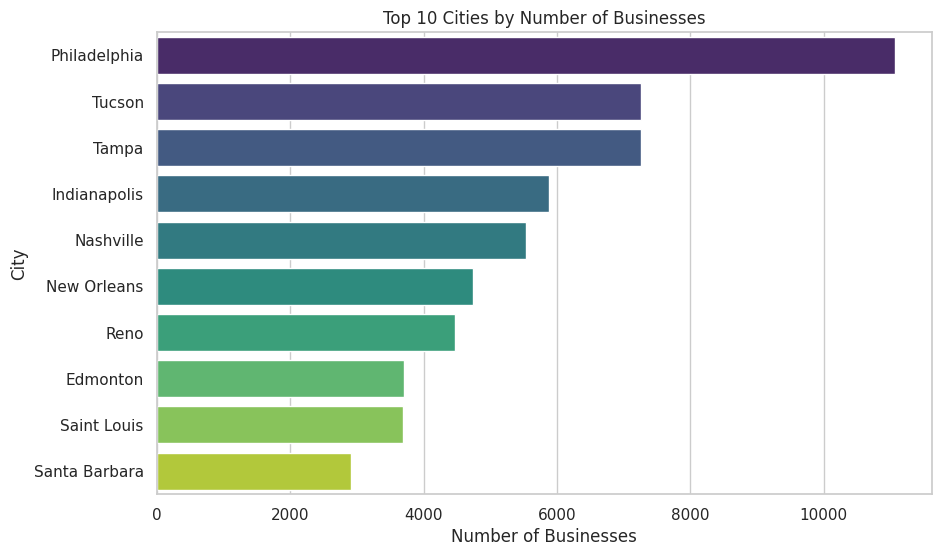

In [8]:
sns.set_theme(style="whitegrid")
print("Querying Top 10 Cities...")
rows_city = session.execute('SELECT city FROM businesses')
df_city = pd.DataFrame(list(rows_city))
city_counts = df_city['city'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index, hue=city_counts.index, palette="viridis", legend=False)
plt.title("Top 10 Cities by Number of Businesses")
plt.xlabel("Number of Businesses")
plt.ylabel("City")
plt.show()

Querying Top Categories...


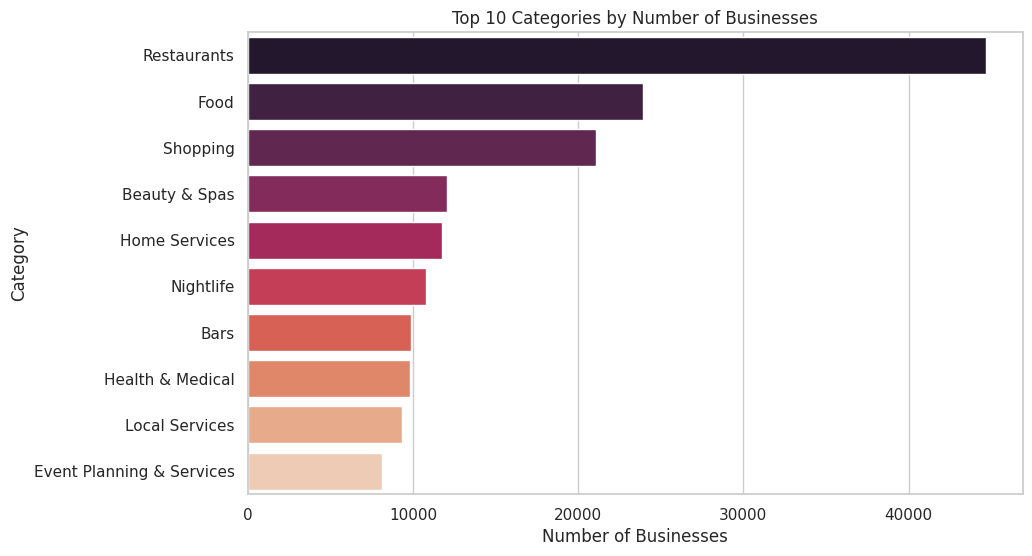

In [9]:
print("Querying Top Categories...")
rows_cat = session.execute('SELECT categories FROM businesses')
df_cat = pd.DataFrame(list(rows_cat))
cat_series = df_cat['categories'].dropna().str.split(r',\s*').explode()
cat_counts = cat_series.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index, palette="rocket", legend=False)
plt.title("Top 10 Categories by Number of Businesses")
plt.xlabel("Number of Businesses")
plt.ylabel("Category")
plt.show()

Querying Stars Distribution...


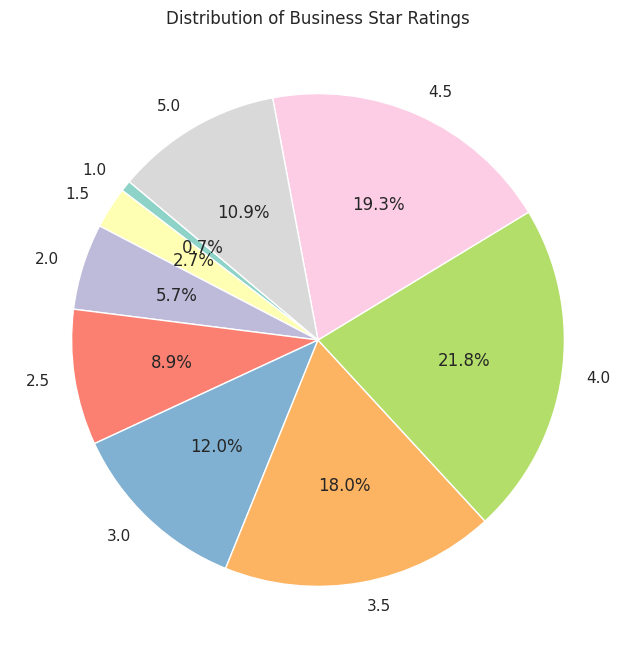

In [10]:
print("Querying Stars Distribution...")
rows_stars = session.execute('SELECT stars FROM businesses')
df_stars = pd.DataFrame(list(rows_stars))
star_counts = df_stars['stars'].value_counts().sort_index()

plt.figure(figsize=(8, 8))
plt.pie(star_counts.values, labels=star_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
plt.title("Distribution of Business Star Ratings")
plt.show()

Plotting Star Frequency Histogram...


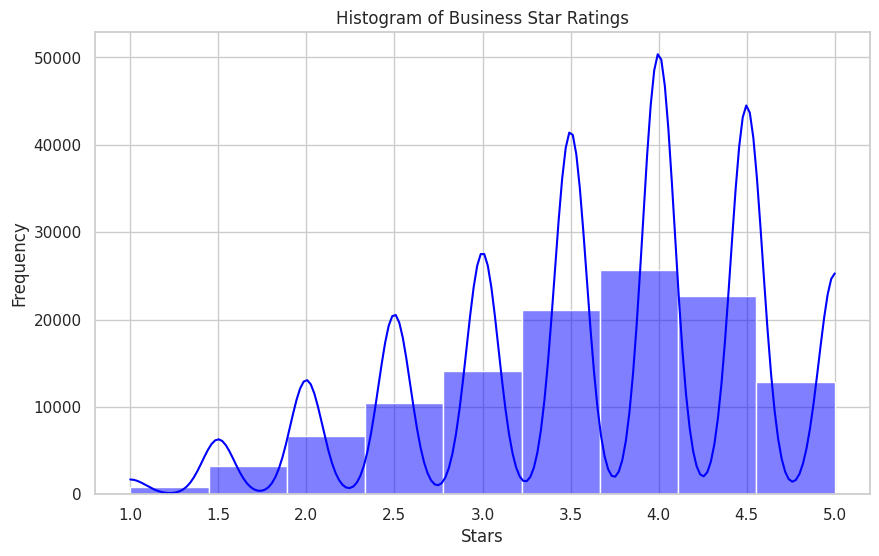

In [11]:
print("Plotting Star Frequency Histogram...")
plt.figure(figsize=(10, 6))
sns.histplot(df_stars['stars'].dropna(), bins=9, kde=True, color="blue")
plt.title("Histogram of Business Star Ratings")
plt.xlabel("Stars")
plt.ylabel("Frequency")
plt.show()

Querying Review Counts Histogram...


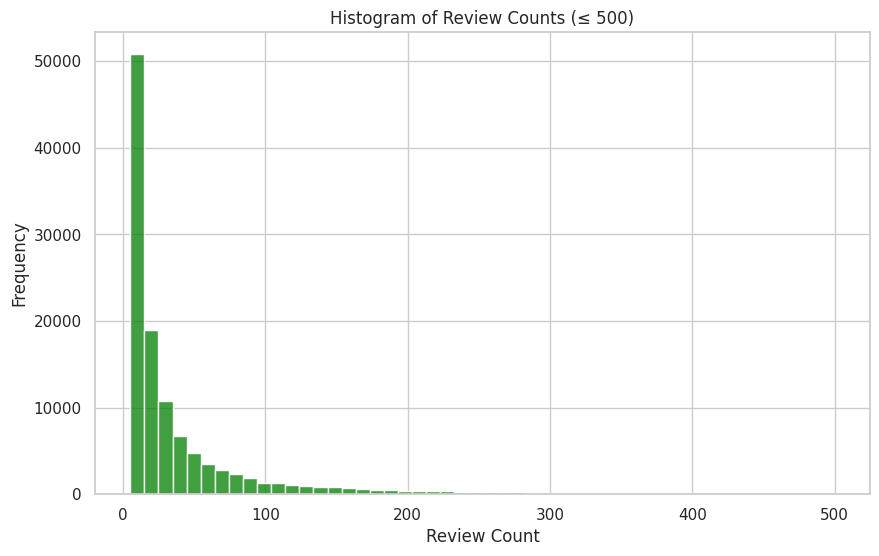

In [12]:
print("Querying Review Counts Histogram...")
rows_reviews = session.execute('SELECT review_count FROM businesses')
df_review_counts = pd.DataFrame(list(rows_reviews))

plt.figure(figsize=(10, 6))
filtered_reviews = df_review_counts[df_review_counts['review_count'] <= 500]
sns.histplot(filtered_reviews['review_count'].dropna(), bins=50, color="green")
plt.title("Histogram of Review Counts (≤ 500)")
plt.xlabel("Review Count")
plt.ylabel("Frequency")
plt.show()

## Analytical Insights
- **Geography**: Geolocation highlights clustering of businesses in major metropolitan hubs (Philadelphia & Tucson).
- **Category Dominance**: Food and Restaurants heavily dominate the Yelp dataset.
- **Ratings Skew**: The star distribution is strongly left-skewed, showing users are measurably more likely to leave positive reviews for good experiences than negative ones.
- **Long Tail Review Model**: The histogram proves a massive majority of businesses have fewer than 50 reviews, while an elite fraction acquires thousands.